In [1]:
import glob
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.dummy import DummyClassifier
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [2]:
RANDOM_STATE = 42


SVM_TEXT_FEATURES = 5000
RF_TEXT_FEATURES = 800


RUN_RANDOM_FOREST = True

USE_SAMPLE = False
SAMPLE_SIZE = 30000

In [3]:
def find_file(pattern):
    files = glob.glob("/content/" + pattern)

    if len(files) == 0:
        raise FileNotFoundError(f"Cannot find file: {pattern}")

    return files[0]

q1_path = find_file("steam_cleaned_with_q1_labels*.csv")
q2_path = find_file("steam_cleaned_with_q2_labels*.csv")

print("Q1 clean file:", q1_path)
print("Q2 clean file:", q2_path)

Q1 clean file: /content/steam_cleaned_with_q1_labels.csv
Q2 clean file: /content/steam_cleaned_with_q2_labels.csv


In [4]:
q1_df = pd.read_csv(q1_path)
q2_df = pd.read_csv(q2_path)

print("Q1 clean shape:", q1_df.shape)
print("Q2 clean shape:", q2_df.shape)

print("Q1 columns:")
print(q1_df.columns.tolist())

print("\nQ2 columns:")
print(q2_df.columns.tolist())

display(q1_df.head())
display(q2_df.head())

Q1 clean shape: (124146, 36)
Q2 clean shape: (30621, 37)
Q1 columns:
['appID', 'name', 'release_date', 'required_age', 'price', 'dlc_count', 'supported_languages', 'full_audio_languages', 'windows', 'mac', 'linux', 'achievements', 'developers', 'publishers', 'categories', 'genres', 'tags', 'short_description', 'detailed_description', 'estimated_owners', 'peak_ccu', 'positive', 'negative', 'recommendations', 'user_score', 'metacritic_score', 'average_playtime_forever', 'median_playtime_forever', 'average_playtime_2weeks', 'median_playtime_2weeks', 'release_date_parsed', 'release_year', 'estimated_owners_mid', 'popular', 'total_reviews', 'positive_ratio']

Q2 columns:
['appID', 'name', 'release_date', 'required_age', 'price', 'dlc_count', 'supported_languages', 'full_audio_languages', 'windows', 'mac', 'linux', 'achievements', 'developers', 'publishers', 'categories', 'genres', 'tags', 'short_description', 'detailed_description', 'estimated_owners', 'peak_ccu', 'positive', 'negative', 'r

,appID,name,release_date,required_age,price,dlc_count,supported_languages,full_audio_languages,windows,mac,...,average_playtime_forever,median_playtime_forever,average_playtime_2weeks,median_playtime_2weeks,release_date_parsed,release_year,estimated_owners_mid,popular,total_reviews,positive_ratio
0,2539430,Black Dragon Mage Playtest,"Aug 1, 2023",0,0.00,0,[],[],True,False,...,0,0,0,0,2023-08-01,2023,0.0,0,0,0.000000
1,496350,Supipara - Chapter 1 Spring Has Come!,"Jul 29, 2016",0,5.24,0,['English'],[],True,False,...,8,8,0,0,2016-07-29,2016,10000.0,0,255,0.988235
2,1034400,Mystery Solitaire The Black Raven,"May 6, 2019",0,4.99,0,['English' 'French' 'German' 'Russian'],[],True,True,...,0,0,0,0,2019-05-06,2019,10000.0,0,24,0.875000
3,3292190,버튜버 파라노이아 - Vtuber Paranoia,"Oct 31, 2024",0,8.99,1,['Korean'],['Korean'],True,False,...,0,0,0,0,2024-10-31,2024,10000.0,0,0,0.000000
4,3631080,Maze Quest VR,"Apr 24, 2025",0,4.99,0,['English'],['English'],True,False,...,0,0,0,0,2025-04-24,2025,10000.0,0,0,0.000000


,appID,name,release_date,required_age,price,dlc_count,supported_languages,full_audio_languages,windows,mac,...,median_playtime_forever,average_playtime_2weeks,median_playtime_2weeks,release_date_parsed,release_year,estimated_owners_mid,popular,total_reviews,positive_ratio,highly_positive
0,496350,Supipara - Chapter 1 Spring Has Come!,"Jul 29, 2016",0,5.24,0,['English'],[],True,False,...,8,0,0,2016-07-29,2016,10000.0,1,255,0.988235,1
1,1934300,Armored Brigade II,"Apr 8, 2025",0,35.99,1,['English'],[],True,False,...,1253,0,0,2025-04-08,2025,10000.0,1,130,0.900000,1
2,1108640,OMNIMUS,"Sep 25, 2019",0,0.99,1,['English' 'Russian'],[],True,True,...,0,0,0,2019-09-25,2019,10000.0,1,53,0.886792,1
3,1025440,Fantasy General II,"Sep 5, 2019",0,13.99,4,['English' 'German' 'Spanish - Spain' 'Simplif...,[],True,False,...,52,0,0,2019-09-05,2019,150000.0,1,1235,0.829960,1
4,2113450,"Forests, Fields and Fortresses","Apr 5, 2023",0,1.49,0,['English' 'Russian'],[],True,True,...,0,0,0,2023-04-05,2023,10000.0,1,66,0.969697,1


In [5]:
print("Q1 target: popular")
print(q1_df["popular"].value_counts())
print(q1_df["popular"].value_counts(normalize=True).round(4))

print("\nQ2 target: highly_positive")
print(q2_df["highly_positive"].value_counts())
print(q2_df["highly_positive"].value_counts(normalize=True).round(4))

Q1 target: popular
popular
0    98578
1    25568
Name: count, dtype: int64
popular
0    0.794
1    0.206
Name: proportion, dtype: float64

Q2 target: highly_positive
highly_positive
1    16883
0    13738
Name: count, dtype: int64
highly_positive
1    0.5514
0    0.4486
Name: proportion, dtype: float64


In [6]:
numeric_cols = [
    "release_year",
    "required_age",
    "price",
    "dlc_count",
    "windows",
    "mac",
    "linux",
    "achievements"
]

text_cols = [
    "supported_languages",
    "full_audio_languages",
    "developers",
    "publishers",
    "categories",
    "genres",
    "tags",
    "short_description",
    "detailed_description"
]

metadata_cols = [
    "appID",
    "name",
    "genres",
    "categories",
    "tags",
    "short_description"
]

In [7]:
def prepare_xy(df, target_col):
    df = df.copy()

    available_numeric_cols = [c for c in numeric_cols if c in df.columns]
    available_text_cols = [c for c in text_cols if c in df.columns]
    available_metadata_cols = [c for c in metadata_cols if c in df.columns]

    for col in available_numeric_cols:
        if df[col].dtype == bool:
            df[col] = df[col].astype(int)

    for col in available_text_cols:
        df[col] = df[col].fillna("").astype(str)

    df["combined_text"] = df[available_text_cols].agg(" ".join, axis=1)

    X = df[available_numeric_cols + ["combined_text"]].copy()
    y = df[target_col].astype(int).copy()
    metadata = df[available_metadata_cols].copy()

    return X, y, metadata, available_numeric_cols

In [8]:
q1_X, q1_y, q1_metadata, q1_numeric_cols = prepare_xy(q1_df, "popular")

print("Q1 X shape:", q1_X.shape)
print("Q1 y shape:", q1_y.shape)
display(q1_X.head())

Q1 X shape: (124146, 9)
Q1 y shape: (124146,)


,release_year,required_age,price,dlc_count,windows,mac,linux,achievements,combined_text
0,2023,0,0.00,0,1,0,0,0,[] [] [] [] [] [] []
1,2016,0,5.24,0,1,0,0,0,['English'] [] ['minori'] ['MangaGamer'] ['Sin...
2,2019,0,4.99,0,1,1,0,0,['English' 'French' 'German' 'Russian'] [] ['S...
3,2024,0,8.99,1,1,0,0,19,['Korean'] ['Korean'] ['유진게임즈'] ['유진게임즈'] ['Si...
4,2025,0,4.99,0,1,0,0,0,['English'] ['English'] ['Reality Expanded LLC...


In [9]:
q2_X, q2_y, q2_metadata, q2_numeric_cols = prepare_xy(q2_df, "highly_positive")

print("Q2 X shape:", q2_X.shape)
print("Q2 y shape:", q2_y.shape)
display(q2_X.head())

Q2 X shape: (30621, 9)
Q2 y shape: (30621,)


,release_year,required_age,price,dlc_count,windows,mac,linux,achievements,combined_text
0,2016,0,5.24,0,1,0,0,0,['English'] [] ['minori'] ['MangaGamer'] ['Sin...
1,2025,0,35.99,1,1,0,0,0,['English'] [] ['Veitikka Studios'] ['Matrix G...
2,2019,0,0.99,1,1,1,1,0,['English' 'Russian'] [] ['Angry games'] ['Tot...
3,2019,0,13.99,4,1,0,0,77,['English' 'German' 'Spanish - Spain' 'Simplif...
4,2023,0,1.49,0,1,1,0,13,['English' 'Russian'] [] ['9 Eyes Game Studio'...


In [10]:
def split_dataset(X, y, metadata):
    X_train, X_temp, y_train, y_temp, metadata_train, metadata_temp = train_test_split(
        X,
        y,
        metadata,
        test_size=0.30,
        random_state=RANDOM_STATE,
        stratify=y
    )

    X_val, X_test, y_val, y_test, metadata_val, metadata_test = train_test_split(
        X_temp,
        y_temp,
        metadata_temp,
        test_size=0.50,
        random_state=RANDOM_STATE,
        stratify=y_temp
    )

    return X_train, X_val, X_test, y_train, y_val, y_test, metadata_train, metadata_val, metadata_test

In [11]:
q1_X_train, q1_X_val, q1_X_test, q1_y_train, q1_y_val, q1_y_test, q1_meta_train, q1_meta_val, q1_meta_test = split_dataset(
    q1_X,
    q1_y,
    q1_metadata
)

print("Q1 train:", q1_X_train.shape)
print("Q1 validation:", q1_X_val.shape)
print("Q1 test:", q1_X_test.shape)

Q1 train: (86902, 9)
Q1 validation: (18622, 9)
Q1 test: (18622, 9)


In [12]:
q2_X_train, q2_X_val, q2_X_test, q2_y_train, q2_y_val, q2_y_test, q2_meta_train, q2_meta_val, q2_meta_test = split_dataset(
    q2_X,
    q2_y,
    q2_metadata
)

print("Q2 train:", q2_X_train.shape)
print("Q2 validation:", q2_X_val.shape)
print("Q2 test:", q2_X_test.shape)

Q2 train: (21434, 9)
Q2 validation: (4593, 9)
Q2 test: (4594, 9)


In [13]:
def build_preprocessor(numeric_columns, max_text_features):
    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler(with_mean=False))
    ])

    text_transformer = TfidfVectorizer(
        max_features=max_text_features,
        stop_words="english",
        ngram_range=(1, 2),
        min_df=2,
        sublinear_tf=True
    )

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_columns),
            ("text", text_transformer, "combined_text")
        ]
    )

    return preprocessor

In [14]:
def calculate_metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "precision_positive": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        "recall_positive": recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        "f1_positive": f1_score(y_true, y_pred, pos_label=1, zero_division=0)
    }

In [15]:
all_results = []

def evaluate_model(task_name, model_name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    metrics = calculate_metrics(y_test, y_pred)

    print("=" * 80)
    print(f"{task_name} | {model_name}")
    print("=" * 80)
    print(pd.Series(metrics).round(4))

    print("\nClassification report:")
    print(classification_report(y_test, y_pred, zero_division=0))

    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["0", "1"])
    disp.plot(values_format="d")
    plt.title(f"{task_name} - {model_name} Confusion Matrix")
    plt.show()

    result_row = {
        "task": task_name,
        "model": model_name,
        **metrics
    }

    all_results.append(result_row)

    return y_pred

In [16]:
def tune_model(model_name, make_model_function, param_grid, X_train, y_train, X_val, y_val):
    best_score = -1
    best_params = None
    best_model = None

    tuning_results = []

    for params in ParameterGrid(param_grid):
        model = make_model_function(params)
        model.fit(X_train, y_train)

        y_val_pred = model.predict(X_val)
        metrics = calculate_metrics(y_val, y_val_pred)
        score = metrics["f1_macro"]

        print("Params:", params, "| validation f1_macro:", round(score, 4))

        row = {
            "model": model_name,
            **params,
            **metrics
        }
        tuning_results.append(row)

        if score > best_score:
            best_score = score
            best_params = params
            best_model = model

    print("\nBest params:", best_params)
    print("Best validation f1_macro:", round(best_score, 4))

    return best_model, best_params, pd.DataFrame(tuning_results)

Q1_popularity | Dummy Baseline
accuracy              0.7941
precision_macro       0.3970
recall_macro          0.5000
f1_macro              0.4426
precision_positive    0.0000
recall_positive       0.0000
f1_positive           0.0000
dtype: float64

Classification report:
              precision    recall  f1-score   support

           0       0.79      1.00      0.89     14787
           1       0.00      0.00      0.00      3835

    accuracy                           0.79     18622
   macro avg       0.40      0.50      0.44     18622
weighted avg       0.63      0.79      0.70     18622



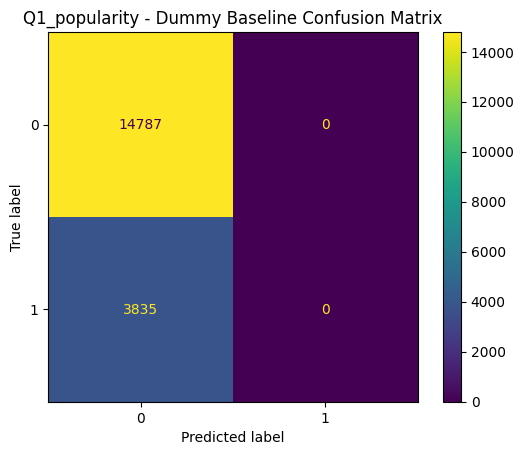

In [17]:
q1_dummy = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
q1_dummy.fit(q1_X_train, q1_y_train)

q1_dummy_pred = evaluate_model(
    task_name="Q1_popularity",
    model_name="Dummy Baseline",
    model=q1_dummy,
    X_test=q1_X_test,
    y_test=q1_y_test
)

In [18]:
def make_q1_svm(params):
    model = Pipeline(steps=[
        ("preprocessor", build_preprocessor(q1_numeric_cols, SVM_TEXT_FEATURES)),
        ("classifier", LinearSVC(
            random_state=RANDOM_STATE,
            max_iter=10000,
            dual=False,
            C=params["C"],
            class_weight=params["class_weight"]
        ))
    ])
    return model

svm_param_grid = {
    "C": [0.1, 1, 10],
    "class_weight": [None, "balanced"]
}

q1_svm, q1_svm_best_params, q1_svm_tuning = tune_model(
    model_name="Q1 Linear SVM",
    make_model_function=make_q1_svm,
    param_grid=svm_param_grid,
    X_train=q1_X_train,
    y_train=q1_y_train,
    X_val=q1_X_val,
    y_val=q1_y_val
)

Params: {'C': 0.1, 'class_weight': None} | validation f1_macro: 0.6797
Params: {'C': 0.1, 'class_weight': 'balanced'} | validation f1_macro: 0.6874
Params: {'C': 1, 'class_weight': None} | validation f1_macro: 0.6768
Params: {'C': 1, 'class_weight': 'balanced'} | validation f1_macro: 0.6801
Params: {'C': 10, 'class_weight': None} | validation f1_macro: 0.682
Params: {'C': 10, 'class_weight': 'balanced'} | validation f1_macro: 0.6881

Best params: {'C': 10, 'class_weight': 'balanced'}
Best validation f1_macro: 0.6881


Q1_popularity | Linear SVM
accuracy              0.7539
precision_macro       0.6726
recall_macro          0.7321
f1_macro              0.6850
precision_positive    0.4385
recall_positive       0.6949
f1_positive           0.5377
dtype: float64

Classification report:
              precision    recall  f1-score   support

           0       0.91      0.77      0.83     14787
           1       0.44      0.69      0.54      3835

    accuracy                           0.75     18622
   macro avg       0.67      0.73      0.69     18622
weighted avg       0.81      0.75      0.77     18622



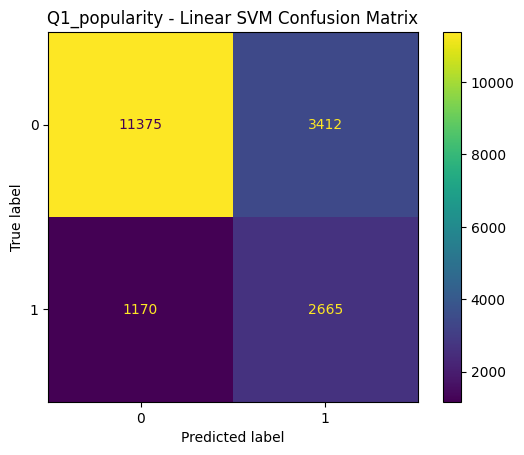

In [19]:
q1_svm_pred = evaluate_model(
    task_name="Q1_popularity",
    model_name="Linear SVM",
    model=q1_svm,
    X_test=q1_X_test,
    y_test=q1_y_test
)

In [20]:
if RUN_RANDOM_FOREST:
    def make_q1_rf(params):
        model = Pipeline(steps=[
            ("preprocessor", build_preprocessor(q1_numeric_cols, RF_TEXT_FEATURES)),
            ("classifier", RandomForestClassifier(
                random_state=RANDOM_STATE,
                n_jobs=-1,
                n_estimators=params["n_estimators"],
                max_depth=params["max_depth"],
                min_samples_leaf=params["min_samples_leaf"],
                class_weight=params["class_weight"]
            ))
        ])
        return model

    rf_param_grid = {
        "n_estimators": [100],
        "max_depth": [20, None],
        "min_samples_leaf": [1, 3],
        "class_weight": [None, "balanced"]
    }

    q1_rf, q1_rf_best_params, q1_rf_tuning = tune_model(
        model_name="Q1 Random Forest",
        make_model_function=make_q1_rf,
        param_grid=rf_param_grid,
        X_train=q1_X_train,
        y_train=q1_y_train,
        X_val=q1_X_val,
        y_val=q1_y_val
    )

Params: {'class_weight': None, 'max_depth': 20, 'min_samples_leaf': 1, 'n_estimators': 100} | validation f1_macro: 0.6907
Params: {'class_weight': None, 'max_depth': 20, 'min_samples_leaf': 3, 'n_estimators': 100} | validation f1_macro: 0.6843
Params: {'class_weight': None, 'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 100} | validation f1_macro: 0.7017
Params: {'class_weight': None, 'max_depth': None, 'min_samples_leaf': 3, 'n_estimators': 100} | validation f1_macro: 0.6975
Params: {'class_weight': 'balanced', 'max_depth': 20, 'min_samples_leaf': 1, 'n_estimators': 100} | validation f1_macro: 0.7329
Params: {'class_weight': 'balanced', 'max_depth': 20, 'min_samples_leaf': 3, 'n_estimators': 100} | validation f1_macro: 0.7384
Params: {'class_weight': 'balanced', 'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 100} | validation f1_macro: 0.6932
Params: {'class_weight': 'balanced', 'max_depth': None, 'min_samples_leaf': 3, 'n_estimators': 100} | validation f1_macro:

Q1_popularity | Random Forest
accuracy              0.8391
precision_macro       0.7573
recall_macro          0.7200
f1_macro              0.7354
precision_positive    0.6341
recall_positive       0.5173
f1_positive           0.5698
dtype: float64

Classification report:
              precision    recall  f1-score   support

           0       0.88      0.92      0.90     14787
           1       0.63      0.52      0.57      3835

    accuracy                           0.84     18622
   macro avg       0.76      0.72      0.74     18622
weighted avg       0.83      0.84      0.83     18622



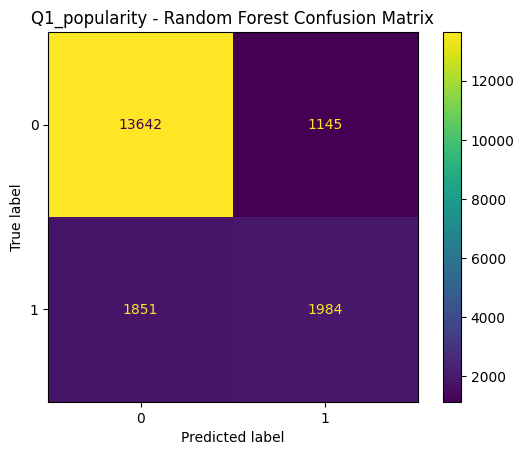

In [21]:
if RUN_RANDOM_FOREST:
    q1_rf_pred = evaluate_model(
        task_name="Q1_popularity",
        model_name="Random Forest",
        model=q1_rf,
        X_test=q1_X_test,
        y_test=q1_y_test
    )

Q2_highly_positive_reviews | Dummy Baseline
accuracy              0.5514
precision_macro       0.2757
recall_macro          0.5000
f1_macro              0.3554
precision_positive    0.5514
recall_positive       1.0000
f1_positive           0.7108
dtype: float64

Classification report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      2061
           1       0.55      1.00      0.71      2533

    accuracy                           0.55      4594
   macro avg       0.28      0.50      0.36      4594
weighted avg       0.30      0.55      0.39      4594



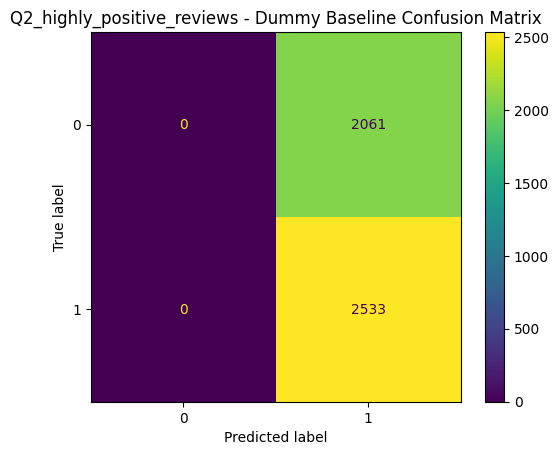

In [22]:
q2_dummy = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
q2_dummy.fit(q2_X_train, q2_y_train)

q2_dummy_pred = evaluate_model(
    task_name="Q2_highly_positive_reviews",
    model_name="Dummy Baseline",
    model=q2_dummy,
    X_test=q2_X_test,
    y_test=q2_y_test
)

In [23]:
def make_q2_svm(params):
    model = Pipeline(steps=[
        ("preprocessor", build_preprocessor(q2_numeric_cols, SVM_TEXT_FEATURES)),
        ("classifier", LinearSVC(
            random_state=RANDOM_STATE,
            max_iter=10000,
            dual=False,
            C=params["C"],
            class_weight=params["class_weight"]
        ))
    ])
    return model

q2_svm, q2_svm_best_params, q2_svm_tuning = tune_model(
    model_name="Q2 Linear SVM",
    make_model_function=make_q2_svm,
    param_grid=svm_param_grid,
    X_train=q2_X_train,
    y_train=q2_y_train,
    X_val=q2_X_val,
    y_val=q2_y_val
)

Params: {'C': 0.1, 'class_weight': None} | validation f1_macro: 0.67
Params: {'C': 0.1, 'class_weight': 'balanced'} | validation f1_macro: 0.668
Params: {'C': 1, 'class_weight': None} | validation f1_macro: 0.6507
Params: {'C': 1, 'class_weight': 'balanced'} | validation f1_macro: 0.6403
Params: {'C': 10, 'class_weight': None} | validation f1_macro: 0.6269
Params: {'C': 10, 'class_weight': 'balanced'} | validation f1_macro: 0.621

Best params: {'C': 0.1, 'class_weight': None}
Best validation f1_macro: 0.67


Q2_highly_positive_reviews | Linear SVM
accuracy              0.6744
precision_macro       0.6711
recall_macro          0.6654
f1_macro              0.6663
precision_positive    0.6868
recall_positive       0.7525
f1_positive           0.7182
dtype: float64

Classification report:
              precision    recall  f1-score   support

           0       0.66      0.58      0.61      2061
           1       0.69      0.75      0.72      2533

    accuracy                           0.67      4594
   macro avg       0.67      0.67      0.67      4594
weighted avg       0.67      0.67      0.67      4594



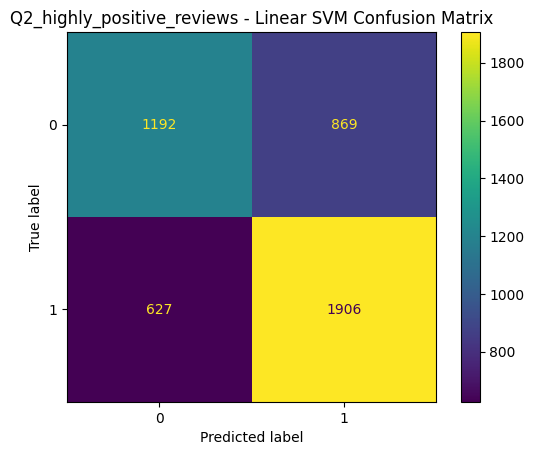

In [24]:
q2_svm_pred = evaluate_model(
    task_name="Q2_highly_positive_reviews",
    model_name="Linear SVM",
    model=q2_svm,
    X_test=q2_X_test,
    y_test=q2_y_test
)

In [25]:
if RUN_RANDOM_FOREST:
    def make_q2_rf(params):
        model = Pipeline(steps=[
            ("preprocessor", build_preprocessor(q2_numeric_cols, RF_TEXT_FEATURES)),
            ("classifier", RandomForestClassifier(
                random_state=RANDOM_STATE,
                n_jobs=-1,
                n_estimators=params["n_estimators"],
                max_depth=params["max_depth"],
                min_samples_leaf=params["min_samples_leaf"],
                class_weight=params["class_weight"]
            ))
        ])
        return model

    q2_rf, q2_rf_best_params, q2_rf_tuning = tune_model(
        model_name="Q2 Random Forest",
        make_model_function=make_q2_rf,
        param_grid=rf_param_grid,
        X_train=q2_X_train,
        y_train=q2_y_train,
        X_val=q2_X_val,
        y_val=q2_y_val
    )

Params: {'class_weight': None, 'max_depth': 20, 'min_samples_leaf': 1, 'n_estimators': 100} | validation f1_macro: 0.6642
Params: {'class_weight': None, 'max_depth': 20, 'min_samples_leaf': 3, 'n_estimators': 100} | validation f1_macro: 0.6668
Params: {'class_weight': None, 'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 100} | validation f1_macro: 0.6657
Params: {'class_weight': None, 'max_depth': None, 'min_samples_leaf': 3, 'n_estimators': 100} | validation f1_macro: 0.6647
Params: {'class_weight': 'balanced', 'max_depth': 20, 'min_samples_leaf': 1, 'n_estimators': 100} | validation f1_macro: 0.6703
Params: {'class_weight': 'balanced', 'max_depth': 20, 'min_samples_leaf': 3, 'n_estimators': 100} | validation f1_macro: 0.6704
Params: {'class_weight': 'balanced', 'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 100} | validation f1_macro: 0.6736
Params: {'class_weight': 'balanced', 'max_depth': None, 'min_samples_leaf': 3, 'n_estimators': 100} | validation f1_macro:

Q2_highly_positive_reviews | Random Forest
accuracy              0.6774
precision_macro       0.6751
recall_macro          0.6670
f1_macro              0.6678
precision_positive    0.6848
recall_positive       0.7687
f1_positive           0.7243
dtype: float64

Classification report:
              precision    recall  f1-score   support

           0       0.67      0.57      0.61      2061
           1       0.68      0.77      0.72      2533

    accuracy                           0.68      4594
   macro avg       0.68      0.67      0.67      4594
weighted avg       0.68      0.68      0.67      4594



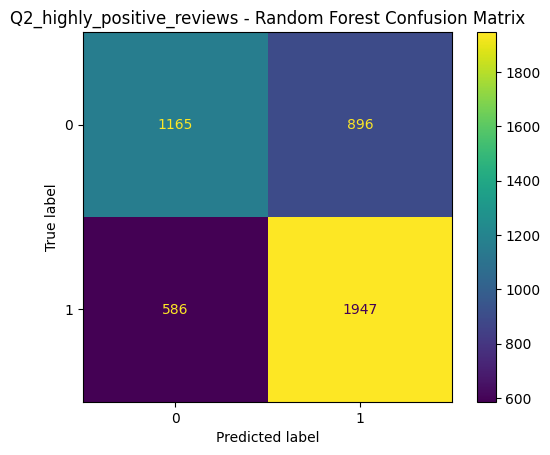

In [26]:
if RUN_RANDOM_FOREST:
    q2_rf_pred = evaluate_model(
        task_name="Q2_highly_positive_reviews",
        model_name="Random Forest",
        model=q2_rf,
        X_test=q2_X_test,
        y_test=q2_y_test
    )

In [27]:
results_df = pd.DataFrame(all_results)

results_df = results_df.sort_values(
    by=["task", "f1_macro"],
    ascending=[True, False]
)

display(results_df.round(4))

results_df.to_csv("traditional_ml_q1_q2_test_results.csv", index=False)

,task,model,accuracy,precision_macro,recall_macro,f1_macro,precision_positive,recall_positive,f1_positive
2,Q1_popularity,Random Forest,0.8391,0.7573,0.7200,0.7354,0.6341,0.5173,0.5698
1,Q1_popularity,Linear SVM,0.7539,0.6726,0.7321,0.6850,0.4385,0.6949,0.5377
0,Q1_popularity,Dummy Baseline,0.7941,0.3970,0.5000,0.4426,0.0000,0.0000,0.0000
5,Q2_highly_positive_reviews,Random Forest,0.6774,0.6751,0.6670,0.6678,0.6848,0.7687,0.7243
4,Q2_highly_positive_reviews,Linear SVM,0.6744,0.6711,0.6654,0.6663,0.6868,0.7525,0.7182
3,Q2_highly_positive_reviews,Dummy Baseline,0.5514,0.2757,0.5000,0.3554,0.5514,1.0000,0.7108


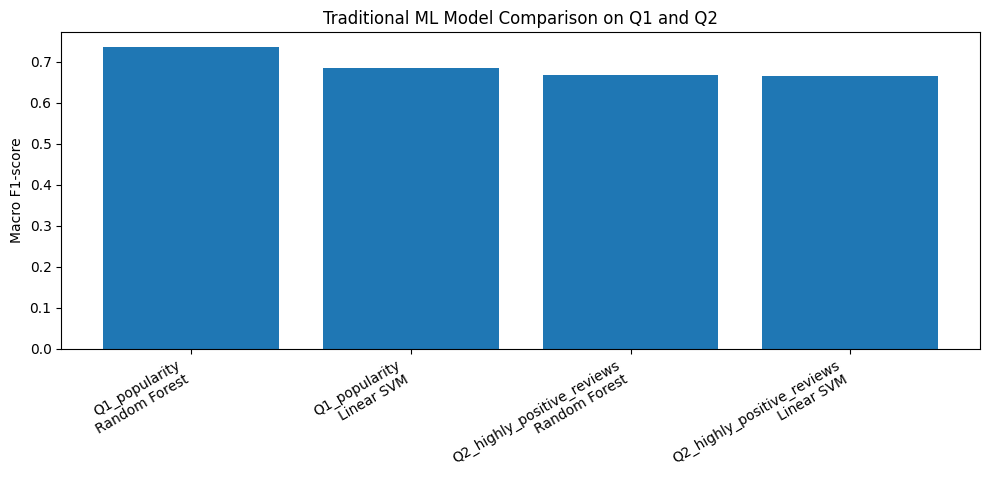

In [28]:
plot_df = results_df[results_df["model"] != "Dummy Baseline"].copy()

plt.figure(figsize=(10, 5))
plt.bar(plot_df["task"] + "\n" + plot_df["model"], plot_df["f1_macro"])
plt.ylabel("Macro F1-score")
plt.title("Traditional ML Model Comparison on Q1 and Q2")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

In [29]:
tuning_tables = [q1_svm_tuning, q2_svm_tuning]

if RUN_RANDOM_FOREST:
    tuning_tables.extend([q1_rf_tuning, q2_rf_tuning])

tuning_df = pd.concat(tuning_tables, ignore_index=True)

display(tuning_df.round(4))

tuning_df.to_csv("traditional_ml_q1_q2_tuning_results.csv", index=False)

,model,C,class_weight,accuracy,precision_macro,recall_macro,f1_macro,precision_positive,recall_positive,f1_positive,max_depth,min_samples_leaf,n_estimators
0,Q1 Linear SVM,0.1,None,0.8392,0.8011,0.6485,0.6797,0.7549,0.3244,0.4538,NaN,NaN,NaN
1,Q1 Linear SVM,0.1,balanced,0.7588,0.6742,0.7303,0.6874,0.4442,0.6819,0.5380,NaN,NaN,NaN
2,Q1 Linear SVM,1.0,None,0.8381,0.7992,0.6461,0.6768,0.7520,0.3194,0.4484,NaN,NaN,NaN
3,Q1 Linear SVM,1.0,balanced,0.7509,0.6681,0.7249,0.6801,0.4333,0.6806,0.5295,NaN,NaN,NaN
4,Q1 Linear SVM,10.0,None,0.8398,0.8014,0.6505,0.6820,0.7546,0.3288,0.4580,NaN,NaN,NaN
5,Q1 Linear SVM,10.0,balanced,0.7575,0.6751,0.7339,0.6881,0.4433,0.6936,0.5409,NaN,NaN,NaN
6,Q2 Linear SVM,0.1,None,0.6769,0.6734,0.6691,0.6700,0.6924,0.7449,0.7177,NaN,NaN,NaN
7,Q2 Linear SVM,0.1,balanced,0.6695,0.6680,0.6696,0.6680,0.7139,0.6682,0.6903,NaN,NaN,NaN
8,Q2 Linear SVM,1.0,None,0.6562,0.6520,0.6502,0.6507,0.6807,0.7089,0.6945,NaN,NaN,NaN
9,Q2 Linear SVM,1.0,balanced,0.6423,0.6402,0.6413,0.6403,0.6848,0.6505,0.6672,NaN,NaN,NaN


In [30]:
def get_misclassified_examples(metadata_test, y_test, y_pred):
    error_df = metadata_test.copy()
    error_df["true_label"] = y_test.values
    error_df["predicted_label"] = y_pred
    error_df["is_error"] = error_df["true_label"] != error_df["predicted_label"]

    def error_type(row):
        if row["true_label"] == row["predicted_label"]:
            return "Correct"
        elif row["true_label"] == 1 and row["predicted_label"] == 0:
            return "False Negative"
        elif row["true_label"] == 0 and row["predicted_label"] == 1:
            return "False Positive"
        else:
            return "Other"

    error_df["error_type"] = error_df.apply(error_type, axis=1)

    return error_df[error_df["is_error"]].copy()

In [31]:
q1_svm_errors = get_misclassified_examples(q1_meta_test, q1_y_test, q1_svm_pred)

print("Q1 Linear SVM misclassified samples:", len(q1_svm_errors))
print(q1_svm_errors["error_type"].value_counts())

display(q1_svm_errors.head(10))

q1_svm_errors.to_csv("q1_linear_svm_misclassified.csv", index=False)

Q1 Linear SVM misclassified samples: 4582
error_type
False Positive    3412
False Negative    1170
Name: count, dtype: int64


,appID,name,genres,categories,tags,short_description,true_label,predicted_label,is_error,error_type
67497,3006550,Hell's Underground,['Action' 'Adventure' 'Casual' 'Indie'],['Single-player' 'Family Sharing'],[],Descend into the eerie depths of the London Un...,0,1,True,False Positive
105642,1118880,Rituals in the Dark,['Indie' 'Simulation'],['Single-player' 'Steam Achievements' 'Steam T...,[],A lesbian / yuri romance story with mild horro...,0,1,True,False Positive
62351,3487660,The Bunker,['Action' 'Adventure' 'Indie'],['Single-player' 'Family Sharing'],[],"Trapped in an abandoned bunker, you are alone—...",1,0,True,False Negative
103000,946000,Captain MaCaw,['Adventure' 'Indie'],['Single-player' 'Steam Achievements' 'Partial...,[],A retro platform adventure in the style of the...,0,1,True,False Positive
70342,679690,SwapQuest,['Casual' 'Indie' 'RPG'],['Single-player' 'Multi-player' 'Co-op' 'Share...,[],SwapQuest is a captivating new mix of easy-to-...,0,1,True,False Positive
42415,1102260,RANK RUNNER,['Action' 'Casual' 'Indie'],['Single-player' 'Full controller support' 'St...,[],Bullet-hell meets endless runner. LITERALLY as...,0,1,True,False Positive
87960,364710,Wonky Pigeon!,['Action' 'Indie'],['Single-player' 'Multi-player' 'Shared/Split ...,[],Engage in the craziest war against humans.. as...,0,1,True,False Positive
23434,2541380,Mystery Box 2: Evolution,['Adventure' 'Indie' 'Strategy'],['Single-player' 'Steam Achievements' 'Family ...,[],Enjoy the 2nd chapter of the Mystery Box game ...,0,1,True,False Positive
14951,1907060,Craft Hero - Prologue,['RPG' 'Simulation' 'Strategy' 'Free To Play'],['Single-player' 'Partial Controller Support'],[],"Gather resources by day, build and recruit by ...",1,0,True,False Negative
50680,2807540,HARSH.,['Action' 'Indie'],['Single-player' 'Steam Achievements' 'Full co...,[],"The agressive, heavy, frantic and HARSH. rogue...",0,1,True,False Positive


In [32]:
if RUN_RANDOM_FOREST:
    q1_rf_errors = get_misclassified_examples(q1_meta_test, q1_y_test, q1_rf_pred)

    print("Q1 Random Forest misclassified samples:", len(q1_rf_errors))
    print(q1_rf_errors["error_type"].value_counts())

    display(q1_rf_errors.head(10))

    q1_rf_errors.to_csv("q1_random_forest_misclassified.csv", index=False)

Q1 Random Forest misclassified samples: 2996
error_type
False Negative    1851
False Positive    1145
Name: count, dtype: int64


,appID,name,genres,categories,tags,short_description,true_label,predicted_label,is_error,error_type
105642,1118880,Rituals in the Dark,['Indie' 'Simulation'],['Single-player' 'Steam Achievements' 'Steam T...,[],A lesbian / yuri romance story with mild horro...,0,1,True,False Positive
62351,3487660,The Bunker,['Action' 'Adventure' 'Indie'],['Single-player' 'Family Sharing'],[],"Trapped in an abandoned bunker, you are alone—...",1,0,True,False Negative
87960,364710,Wonky Pigeon!,['Action' 'Indie'],['Single-player' 'Multi-player' 'Shared/Split ...,[],Engage in the craziest war against humans.. as...,0,1,True,False Positive
29085,1681060,Exogate Initiative,['Simulation' 'Strategy'],['Single-player' 'Steam Achievements' 'Steam W...,[],Build and manage mankind’s first mission acros...,1,0,True,False Negative
14951,1907060,Craft Hero - Prologue,['RPG' 'Simulation' 'Strategy' 'Free To Play'],['Single-player' 'Partial Controller Support'],[],"Gather resources by day, build and recruit by ...",1,0,True,False Negative
2652,671580,NeoCube,['Casual'],['Single-player' 'Steam Achievements' 'Family ...,[],Neocube is the puzzle game in which you try to...,1,0,True,False Negative
90920,447920,Drift (Over) Drive,['Indie' 'Racing'],['Single-player' 'Family Sharing'],[],In DoD you take the role of a driver passionat...,1,0,True,False Negative
36205,1330080,The Fantastic Adventure of Monsieur Grape,['Adventure'],['Single-player' 'Steam Achievements'],[],The Fantastic Adventure of Monsieur Grape is a...,1,0,True,False Negative
25207,1559450,Veneficium: A witch's tale,['Adventure' 'Casual' 'Free To Play' 'Indie'],['Single-player'],[],Veneficium is a cute and magical 3D platformer...,1,0,True,False Negative
11272,924360,Zenith Hunter,['Action' 'Free To Play' 'Indie'],['Single-player' 'Partial Controller Support'],[],Climb to the top of the Zenith in this fast-pa...,1,0,True,False Negative


In [33]:
q2_svm_errors = get_misclassified_examples(q2_meta_test, q2_y_test, q2_svm_pred)

print("Q2 Linear SVM misclassified samples:", len(q2_svm_errors))
print(q2_svm_errors["error_type"].value_counts())

display(q2_svm_errors.head(10))

q2_svm_errors.to_csv("q2_linear_svm_misclassified.csv", index=False)

Q2 Linear SVM misclassified samples: 1496
error_type
False Positive    869
False Negative    627
Name: count, dtype: int64


,appID,name,genres,categories,tags,short_description,true_label,predicted_label,is_error,error_type
1624,1126580,The Captain is Dead,['Strategy'],['Single-player' 'Multi-player' 'Co-op' 'Share...,[],It’s the last 10 minutes of your favorite sci-...,1,0,True,False Negative
9662,437420,The Secret Order 3: Ancient Times,['Adventure' 'Casual'],['Single-player' 'Steam Achievements' 'Steam T...,[],Find a way to destroy the ancient artifacts!,1,0,True,False Negative
27537,564150,Rosenkreuzstilette,['Action' 'Indie'],['Single-player' 'Steam Achievements' 'Full co...,[],Rosenkreuzstilette is a mega-action-platformer...,0,1,True,False Positive
21946,445220,Avorion,['Action' 'Indie' 'Simulation'],['Single-player' 'Multi-player' 'PvP' 'Online ...,[],A procedural co-op space sandbox where players...,1,0,True,False Negative
14701,2585040,GUNVOLT RECORDS Cychronicle,['Action' 'Casual'],['Single-player' 'Steam Achievements' 'Full co...,[],A new rhythm music game starring the songstres...,0,1,True,False Positive
10279,515040,Make America Great Again: The Trump Presidency,['Action' 'Casual' 'Indie' 'Simulation' 'Strat...,['Single-player' 'Steam Achievements' 'Steam T...,[],A Pro-Donald Trump presidential simulation. Ma...,1,0,True,False Negative
12240,948880,Arena Renovation,['Casual' 'Indie' 'Simulation' 'Sports'],['Single-player' 'Steam Achievements' 'Camera ...,[],Take on the role of a one-man renovation team ...,0,1,True,False Positive
13141,437390,HoPiKo,['Action' 'Casual' 'Indie'],['Single-player' 'Steam Achievements' 'Full co...,[],HoPiKo is an intense speed run platformer wher...,0,1,True,False Positive
28695,2485190,MediBang Paint for Desktop,['Animation & Modeling' 'Design & Illustration...,[],[],This is the perfect drawing app for those who ...,0,1,True,False Positive
19333,1288790,BeachHead,['Action' 'Casual' 'Indie' 'Simulation'],['Single-player' 'Steam Achievements' 'Tracked...,[],"BEACHHEAD - IT'S NOT JUST A GAME, IT'S THE FUT...",0,1,True,False Positive


In [34]:
if RUN_RANDOM_FOREST:
    q2_rf_errors = get_misclassified_examples(q2_meta_test, q2_y_test, q2_rf_pred)

    print("Q2 Random Forest misclassified samples:", len(q2_rf_errors))
    print(q2_rf_errors["error_type"].value_counts())

    display(q2_rf_errors.head(10))

    q2_rf_errors.to_csv("q2_random_forest_misclassified.csv", index=False)

Q2 Random Forest misclassified samples: 1482
error_type
False Positive    896
False Negative    586
Name: count, dtype: int64


,appID,name,genres,categories,tags,short_description,true_label,predicted_label,is_error,error_type
16070,41300,Altitude,['Action' 'Casual' 'Free To Play' 'Indie' 'Sim...,['Single-player' 'Multi-player' 'PvP' 'Online ...,[],"Now Available on PC, Mac and Linux!",1,0,True,False Negative
28599,2099680,Rent A Car Simulator 24,['Casual' 'Racing' 'Simulation' 'Early Access'],['Single-player' 'Multi-player' 'Co-op' 'Onlin...,[],Rent A Car Simulator. Start by renting your fi...,0,1,True,False Positive
1624,1126580,The Captain is Dead,['Strategy'],['Single-player' 'Multi-player' 'Co-op' 'Share...,[],It’s the last 10 minutes of your favorite sci-...,1,0,True,False Negative
10120,1045430,Circadian City,['Adventure' 'Indie' 'RPG' 'Simulation' 'Strat...,['Single-player' 'Steam Achievements' 'Partial...,[],A life sim game where you play both in the Rea...,0,1,True,False Positive
221,347250,F-19 Stealth Fighter,['Simulation'],['Single-player' 'Family Sharing'],[],F-19 STEALTH FIGHTER takes combat flying to ne...,1,0,True,False Negative
21946,445220,Avorion,['Action' 'Indie' 'Simulation'],['Single-player' 'Multi-player' 'PvP' 'Online ...,[],A procedural co-op space sandbox where players...,1,0,True,False Negative
23630,1969310,Demeo Battles,['Adventure' 'Indie' 'RPG' 'Strategy'],['Single-player' 'Multi-player' 'PvP' 'Online ...,[],Demeo Battles is a competitive PvP turn-based ...,0,1,True,False Positive
14701,2585040,GUNVOLT RECORDS Cychronicle,['Action' 'Casual'],['Single-player' 'Steam Achievements' 'Full co...,[],A new rhythm music game starring the songstres...,0,1,True,False Positive
10279,515040,Make America Great Again: The Trump Presidency,['Action' 'Casual' 'Indie' 'Simulation' 'Strat...,['Single-player' 'Steam Achievements' 'Steam T...,[],A Pro-Donald Trump presidential simulation. Ma...,1,0,True,False Negative
13141,437390,HoPiKo,['Action' 'Casual' 'Indie'],['Single-player' 'Steam Achievements' 'Full co...,[],HoPiKo is an intense speed run platformer wher...,0,1,True,False Positive
